In [43]:
import pandas as pd
import numpy as np

In [53]:
c5 = pd.read_csv('C:\Hackathon CDMX\Data\C5\inViales_2022_2024.csv')
print(c5.shape)
c5.head()

<>:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
<>:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
C:\Users\diego\AppData\Local\Temp\ipykernel_19144\523999942.py:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
  c5 = pd.read_csv('C:\Hackathon CDMX\Data\C5\inViales_2022_2024.csv')


(504261, 17)


,folio,fecha_creacion,hora_creacion,dia_semana,fecha_cierre,hora_cierre,tipo_incidente_c4,incidente_c4,alcaldia_inicio,codigo_cierre,clas_con_f_alarma,tipo_entrada,alcaldia_cierre,alcaldia_catalogo,colonia_catalogo,longitud,latitud
0,C2C/20211229/00212,2021-12-29,23:21:20,Miércoles,2022-01-01,00:24:06,Lesionado,Atropellado,NaN,I,URGENCIAS MEDICAS,BOTÓN DE AUXILIO,NaN,Cuauhtémoc,Roma Norte,-99.163670,19.421610
1,C2C/20211231/00183,2021-12-31,23:48:03,Viernes,2022-01-01,06:29:52,Lesionado,Atropellado,CUAUHTEMOC,A,URGENCIAS MEDICAS,BOTÓN DE AUXILIO,CUAUHTEMOC,Cuauhtémoc,Obrera,-99.144270,19.409910
2,C2C/20220101/00012,2022-01-01,01:06:39,Sábado,2022-01-01,06:00:12,Accidente,Choque con lesionados,CUAUHTEMOC,A,URGENCIAS MEDICAS,BOTÓN DE AUXILIO,CUAUHTEMOC,Cuauhtémoc,Doctores,-99.148320,19.415250
3,C2C/20220101/00070,2022-01-01,09:51:53,Sábado,2022-01-01,12:54:10,Accidente,Motociclista,CUAUHTEMOC,A,URGENCIAS MEDICAS,RADIO,CUAUHTEMOC,Miguel Hidalgo,Tlaxpana,-99.165781,19.443649
4,C2N/20211231/00128,2021-12-31,23:03:05,Viernes,2022-01-01,06:16:42,Accidente,Choque sin lesionados,IZTACALCO,A,EMERGENCIA,BOTÓN DE AUXILIO,IZTACALCO,Iztacalco,Agricola Pantitlan,-99.060450,19.414620


# PREPROCESAMIENTO Y EDA

In [54]:
df_tlp_risk = c5[(c5['alcaldia_cierre']=='TLALPAN') & (c5['alcaldia_catalogo']=='Tlalpan')]

print(df_tlp_risk.shape)
df_tlp_risk.head()


(34559, 17)


,folio,fecha_creacion,hora_creacion,dia_semana,fecha_cierre,hora_cierre,tipo_incidente_c4,incidente_c4,alcaldia_inicio,codigo_cierre,clas_con_f_alarma,tipo_entrada,alcaldia_cierre,alcaldia_catalogo,colonia_catalogo,longitud,latitud
29,C2S/20220101/00070,2022-01-01,13:19:01,Sábado,2022-01-01,16:24:10,Accidente,Choque sin lesionados,TLALPAN,A,EMERGENCIA,BOTÓN DE AUXILIO,TLALPAN,Tlalpan,Narciso Mendoza,-99.126610,19.290190
37,C5/20211231/04031,2021-12-31,20:52:59,Viernes,2022-01-01,00:04:07,Accidente,Choque sin lesionados,COYOACAN,D,EMERGENCIA,LLAMADA DEL 911,TLALPAN,Tlalpan,Viejo Ejido Santa Ursula Coapa,-99.144623,19.300380
38,C5/20211231/04048,2021-12-31,20:59:05,Viernes,2022-01-01,00:04:08,Accidente,Choque sin lesionados,TLALPAN,F,EMERGENCIA,LLAMADA DEL 911,TLALPAN,Tlalpan,Pedregal De San Nicolas 1a Seccion,-99.232694,19.293983
44,C5/20211231/04125,2021-12-31,21:07:10,Viernes,2022-01-01,00:14:09,Accidente,Choque sin lesionados,TLALPAN,D,EMERGENCIA,LLAMADA DEL 911,TLALPAN,Tlalpan,Pedregal De San Nicolas 1a Seccion,-99.232281,19.293884
47,C5/20211231/04252,2021-12-31,21:29:59,Viernes,2022-01-01,00:34:09,Accidente,Choque con lesionados,TLALPAN,F,URGENCIAS MEDICAS,LLAMADA DEL 911,TLALPAN,Tlalpan,Narciso Mendoza,-99.125036,19.285386


In [55]:
# Crear un DataFrame con el conteo y el porcentaje de nulos
missing_data = pd.DataFrame({
    'Nulos': df_tlp_risk.isnull().sum(),
    'Porcentaje': (df_tlp_risk.isnull().mean() * 100).round(2)
})

# Filtrar solo las columnas que tienen al menos un valor nulo
missing_data = missing_data[missing_data['Nulos'] > 0].sort_values(by='Nulos', ascending=False)

print(missing_data)

                  Nulos  Porcentaje
colonia_catalogo   2778        8.04
tipo_entrada          2        0.01


> Mejor practica:
> * `tipo_entrada`: Rellenar con la moda
> * `colonia_catalogo`: Rellenar con `DESCONOCIDO`

In [56]:
# tipo_entrada
moda_col = df_tlp_risk['tipo_entrada'].mode()[0]
df_tlp_risk['tipo_entrada'] = df_tlp_risk['tipo_entrada'].fillna(moda_col)

# colonia_catalogo
df_tlp_risk['colonia_catalogo'] = df_tlp_risk['colonia_catalogo'].fillna('DESCONOCIDO')

In [57]:
df_tlp_risk.info()

<class 'pandas.DataFrame'>
Index: 34559 entries, 29 to 504236
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   folio              34559 non-null  str    
 1   fecha_creacion     34559 non-null  str    
 2   hora_creacion      34559 non-null  str    
 3   dia_semana         34559 non-null  str    
 4   fecha_cierre       34559 non-null  str    
 5   hora_cierre        34559 non-null  str    
 6   tipo_incidente_c4  34559 non-null  str    
 7   incidente_c4       34559 non-null  str    
 8   alcaldia_inicio    34559 non-null  str    
 9   codigo_cierre      34559 non-null  str    
 10  clas_con_f_alarma  34559 non-null  str    
 11  tipo_entrada       34559 non-null  str    
 12  alcaldia_cierre    34559 non-null  str    
 13  alcaldia_catalogo  34559 non-null  str    
 14  colonia_catalogo   34559 non-null  str    
 15  longitud           34559 non-null  float64
 16  latitud            34559 non-null  f

> Se eliminan columnas que como
> * identificadores unicos: `folio`
> * datos de creacion del folio (lo importante es como termina): `fecha_creacion`, `hora_creacion`, `alcaldia_inicio`
> * columnas con un solo valor: `alcaldia_cierre`

In [58]:
df_tlp_risk.drop(inplace=True, columns=['folio', 'fecha_creacion', 'hora_creacion', 'alcaldia_inicio', 'alcaldia_cierre','alcaldia_catalogo'])

In [62]:
# Convertir fecha_cierre de string a formato fecha (datetime)
df_tlp_risk['fecha_cierre'] = pd.to_datetime(df_tlp_risk['fecha_cierre'], format='%Y-%m-%d')

# Convertir hora_cierre a datetime PRIMERO (para poder usar .dt)
df_tlp_risk['hora_cierre_dt'] = pd.to_datetime(df_tlp_risk['hora_cierre'], format='%H:%M:%S')

# Extraer la hora ANTES de convertir a time
df_tlp_risk['hora'] = df_tlp_risk['hora_cierre_dt'].dt.hour

# AHORA convertir hora_cierre a tipo time (si lo necesitas)
df_tlp_risk['hora_cierre'] = df_tlp_risk['hora_cierre_dt'].dt.time

# Eliminar columna temporal si no la necesitas
df_tlp_risk = df_tlp_risk.drop(columns=['hora_cierre_dt'])

# Arreglar dato mal escrito
df_tlp_risk['tipo_entrada'] = df_tlp_risk['tipo_entrada'].replace('LLAMADA APP911', 'LLAMADA DEL 911')


In [63]:
df_tlp_risk.info()
df_tlp_risk.head(1)

<class 'pandas.DataFrame'>
Index: 34559 entries, 29 to 504236
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   dia_semana         34559 non-null  str           
 1   fecha_cierre       34559 non-null  datetime64[us]
 2   hora_cierre        34559 non-null  object        
 3   tipo_incidente_c4  34559 non-null  str           
 4   incidente_c4       34559 non-null  str           
 5   codigo_cierre      34559 non-null  str           
 6   clas_con_f_alarma  34559 non-null  str           
 7   tipo_entrada       34559 non-null  str           
 8   colonia_catalogo   34559 non-null  str           
 9   longitud           34559 non-null  float64       
 10  latitud            34559 non-null  float64       
 11  hora               34559 non-null  int32         
dtypes: datetime64[us](1), float64(2), int32(1), object(1), str(7)
memory usage: 6.1+ MB


,dia_semana,fecha_cierre,hora_cierre,tipo_incidente_c4,incidente_c4,codigo_cierre,clas_con_f_alarma,tipo_entrada,colonia_catalogo,longitud,latitud,hora
29,Sábado,2022-01-01,16:24:10,Accidente,Choque sin lesionados,A,EMERGENCIA,BOTÓN DE AUXILIO,Narciso Mendoza,-99.12661,19.29019,16


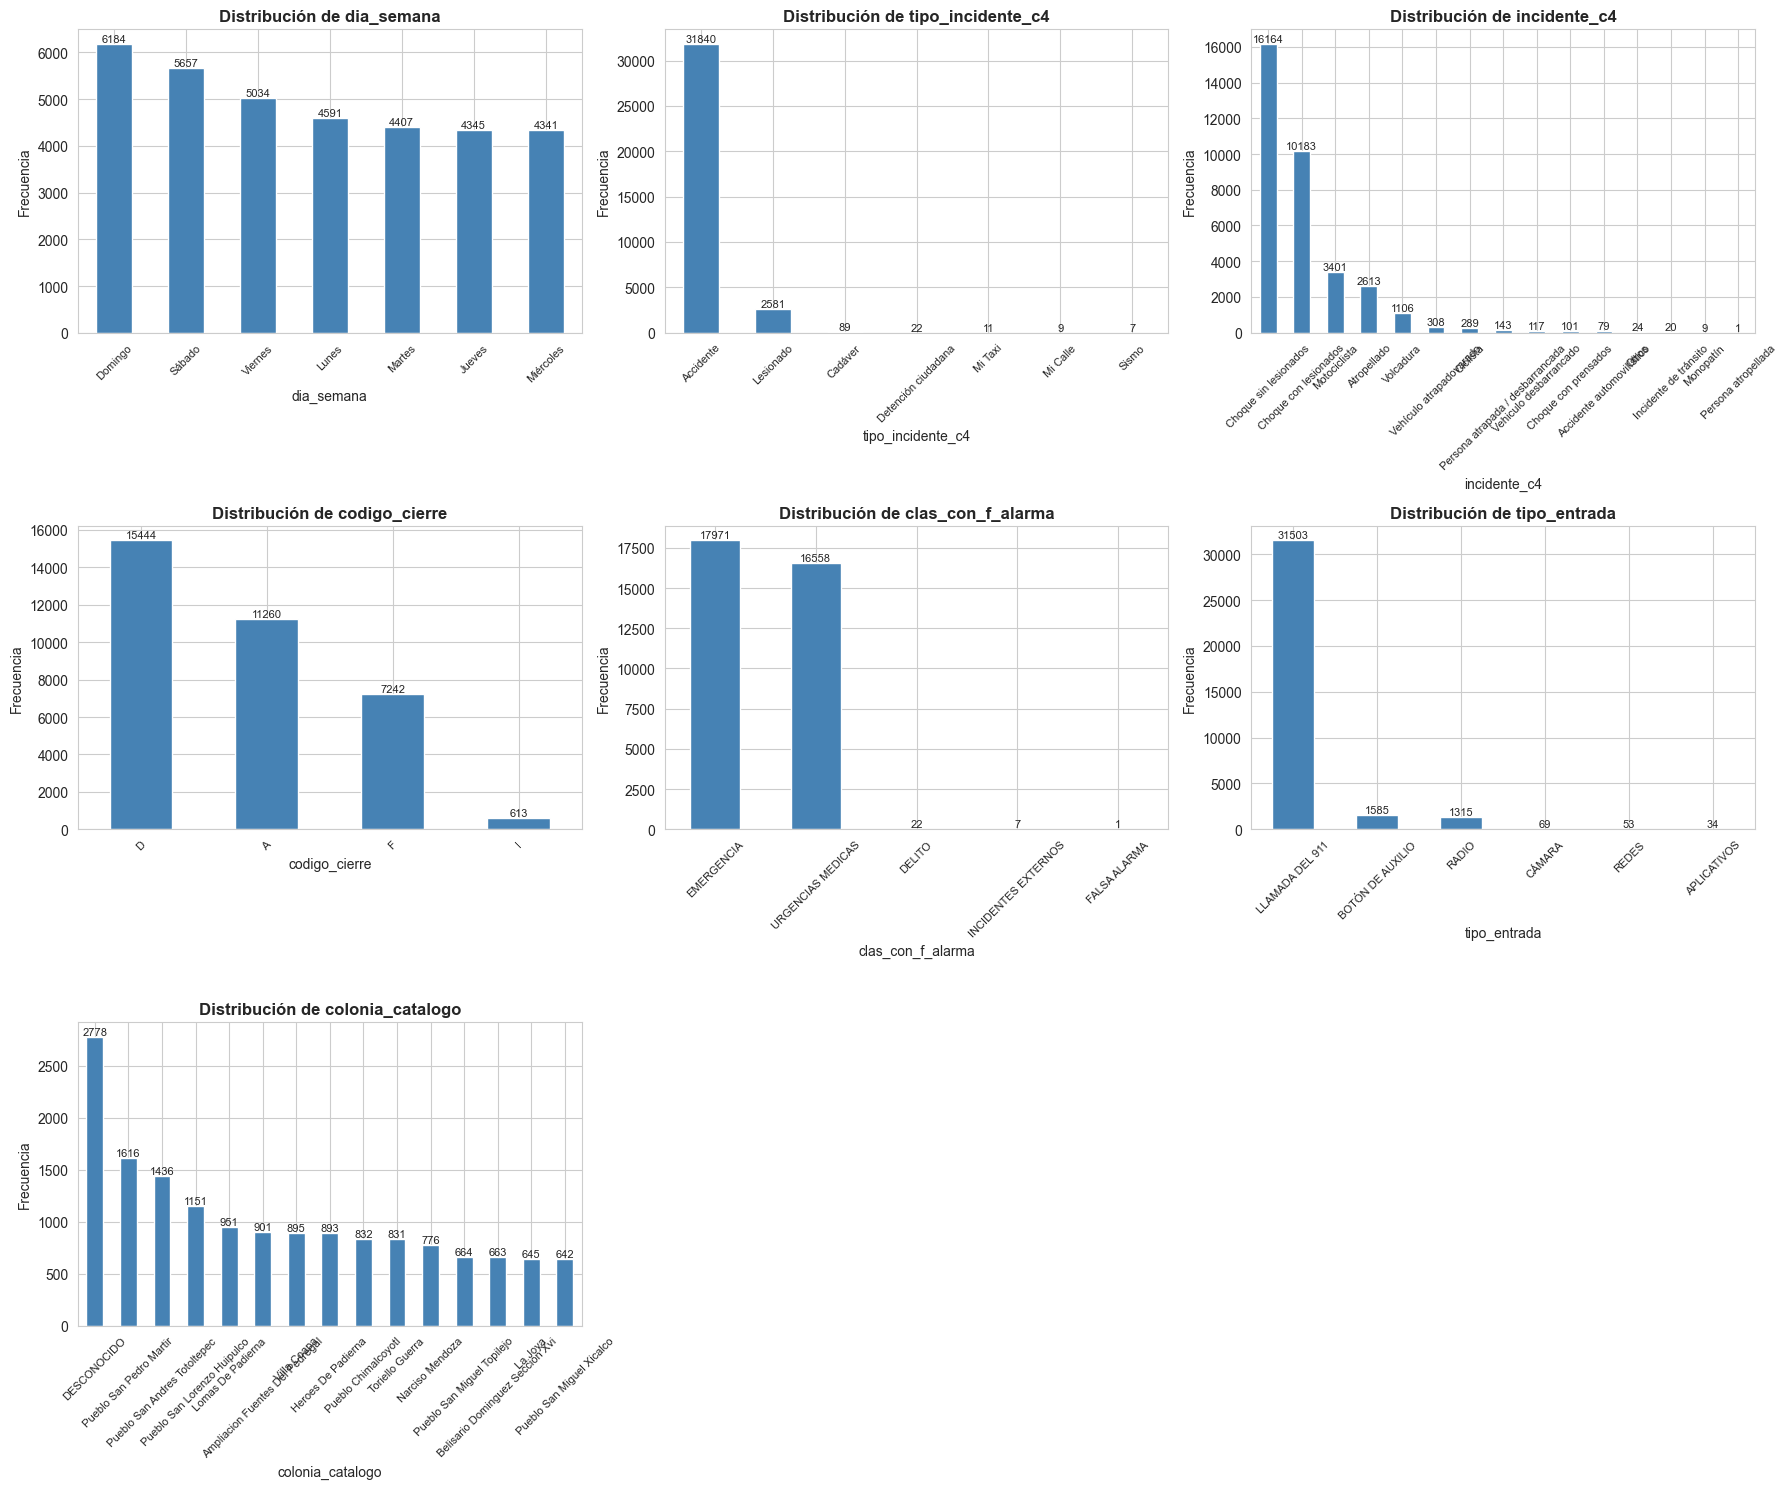


Total de variables categóricas: 7
Variables: dia_semana, tipo_incidente_c4, incidente_c4, codigo_cierre, clas_con_f_alarma, tipo_entrada, colonia_catalogo


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar columnas categóricas (tipo object/string)
categorical_cols = df_tlp_risk.select_dtypes(include=['str']).columns.tolist()

# Configurar el estilo
sns.set_style("whitegrid")

# Crear gráficos de barras para cada variable categórica
n_cols = len(categorical_cols)
n_rows = (n_cols + 2) // 3  # 3 gráficos por fila

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
axes = axes.flatten() if n_cols > 1 else [axes]

for idx, col in enumerate(categorical_cols):
    # Contar valores y tomar los top 15 (para evitar gráficos muy saturados)
    value_counts = df_tlp_risk[col].value_counts().head(15)
    
    # Crear gráfico de barras
    ax = axes[idx]
    value_counts.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    # Añadir valores en las barras
    for i, v in enumerate(value_counts):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)

# Ocultar ejes vacíos si hay menos gráficos que subplots
for idx in range(n_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Mostrar resumen de variables categóricas
print(f"\nTotal de variables categóricas: {n_cols}")
print(f"Variables: {', '.join(categorical_cols)}")


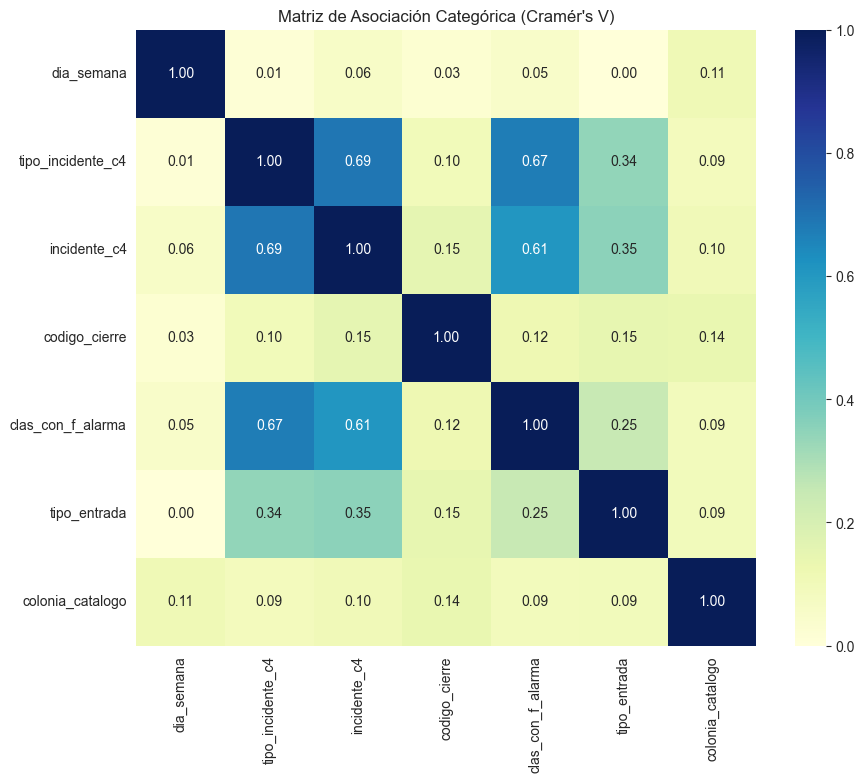

In [65]:
from scipy.stats import chi2_contingency

# 1. Función para Cramér's V (Asociación Categórica)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 2. Matriz de Asociación Categórica (Cramér's V)
if len(categorical_cols) > 1:
    v_results = []
    for col1 in categorical_cols:
        row = []
        for col2 in categorical_cols:
            row.append(cramers_v(df_tlp_risk[col1], df_tlp_risk[col2]))
        v_results.append(row)
    
    v_matrix = pd.DataFrame(v_results, index=categorical_cols, columns=categorical_cols)

    plt.figure(figsize=(10, 8))
    sns.heatmap(v_matrix, annot=True, cmap='YlGnBu', fmt=".2f", vmin=0, vmax=1)
    plt.title("Matriz de Asociación Categórica (Cramér's V)")
    plt.show()

# CREACION NUEVO DF

In [66]:
df_tlp_risk.to_csv('C:\Hackathon CDMX\clean_data\incidentes_c5.csv', index=False)


<>:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
<>:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
C:\Users\diego\AppData\Local\Temp\ipykernel_19144\3014789584.py:1: SyntaxWarning: "\H" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\H"? A raw string is also an option.
  df_tlp_risk.to_csv('C:\Hackathon CDMX\clean_data\incidentes_c5.csv', index=False)
